# Problem A: Recover Young's modulus in 1D Elastostatics
Consider a rod made of linearly elastic material subjected to some load. Static problems will be considered here, by which is meant it is not necessary to know how the load was applied, or how the material particles moved to reach the stressed state; it is necessary only that the load is applied slowly enough so that the accelerations are zero, or that it was applied sufficiently long ago that any vibrations have died away and movement has ceased. 

The equation governing the static response of the rod is: 
$$
-\frac{d}{dx} \left( k(x) \frac{du}{dx} \right) = f, \quad x \in (0, L) \tag{1}
$$
where
- $u(x):$ displacement field of the rod
- $k(x):$ Young’s modulus 
- $f=9.81:$ body force per unit length (e.g., gravity)
- $L=1.:$ Length of the rod

We consider the fixation of both sides of the rod, which leads to the following boundary conditions:
- $u(0) = u(L) = 0$

## Task: Recover the Young's modulus $k(x)$ from the observation of displacement field $u(x)$
In this task, the Young's modulus $k(x)>0$ of the rod is unknown. However, we observe the displacement field $u_{obs}$ (contaminated by noise with noise level $\sim 5\%$) on a set of randomly placed sensors $x_{obs}$ (with size $N_{obs}=500$).

### The goals
- Please select a suitable deep learning method for solving this inverse problem to recover the Young's modulus $k(x)$, and explain the reason for using it
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on testing dataset) at each training epoch and plot the ```Error vs. epoch``` curve (and report the final error). The $L^2$ relative error between the prediction $k_{pred} (or\ u_{pred})$ and the truth $k_{true} (or\ u_{true})$ is defined as follows:
  $$error = \sqrt{\frac{\sum^{n}_i|k_{pred}(x_i)-k_{true}(x_i)|^2}{\sum^{n}_{i}|k_{true}(x_i)|^2}}$$
- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with ```matplotlib```.
  
### Dataset
The observation and the ground truth references are given in the dataset ```ProblemA_dataset.h5```:
- ```x_obs```: the observation sensors 
- ```u_obs```: the observed displacement field $u$ (contaminated by noise)
- ```x_test```: the locations where the ground truth is evaluated (Used for computing error and should **not** be used for training)
- ```k_test```: the ground truth reference for Young's modulus (Used for computing error and should **not** be used for training)
- ```u_test```: the ground truth reference for displacement field (Used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

Epoch:499, The loss is:0.003083650954067707, LEARNING_RATE_k: 0.001
Epoch:999, The loss is:0.00306254206225276, LEARNING_RATE_k: 0.001
Epoch:1499, The loss is:0.0030547278001904488, LEARNING_RATE_k: 0.001
Epoch:1999, The loss is:0.003050193889066577, LEARNING_RATE_k: 0.001
Epoch:2499, The loss is:0.0030464937444776297, LEARNING_RATE_k: 0.001
Epoch:2999, The loss is:0.003042876720428467, LEARNING_RATE_k: 0.001
Epoch:3499, The loss is:0.0030237429309636354, LEARNING_RATE_k: 0.001
Epoch:3999, The loss is:0.0011338109616190195, LEARNING_RATE_k: 0.001
Epoch:4499, The loss is:0.0009216939797624946, LEARNING_RATE_k: 0.001
Epoch:4999, The loss is:0.0008994363015517592, LEARNING_RATE_k: 0.0005
Epoch:5499, The loss is:0.0008850329322740436, LEARNING_RATE_k: 0.0005
Epoch:5999, The loss is:0.0008810635772533715, LEARNING_RATE_k: 0.0005
Epoch:6499, The loss is:0.000882754335179925, LEARNING_RATE_k: 0.0005
Epoch:6999, The loss is:0.0008782362565398216, LEARNING_RATE_k: 0.0005
Epoch:7499, The loss is

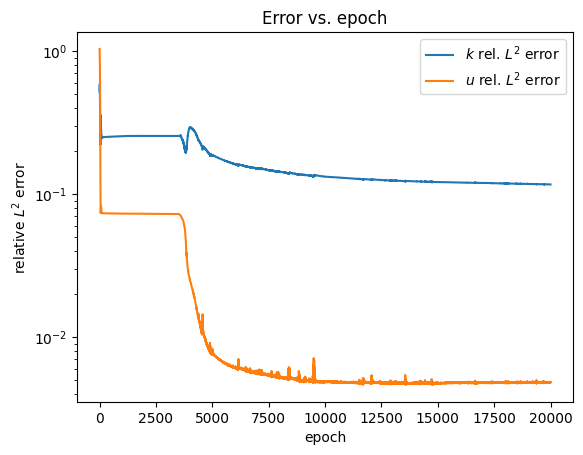

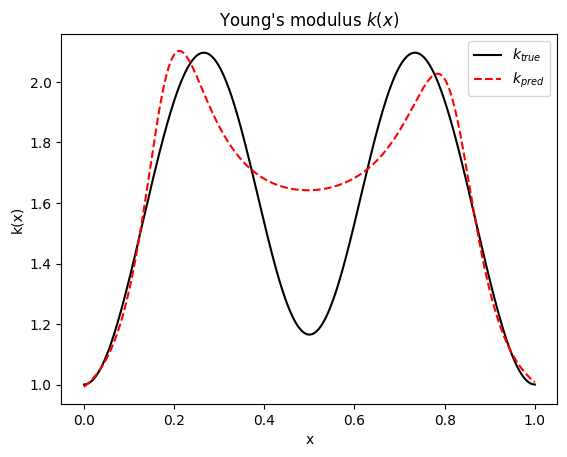

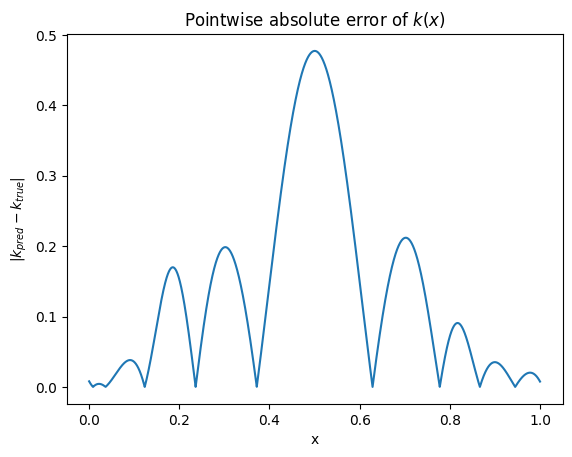

In [ ]:
import h5py
import pathlib
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad, Variable
import matplotlib.pyplot as plt

np.random.seed(67)
torch.manual_seed(67)

DEVICE = torch.device('cuda')
DATA_TYPE = torch.float32
LEARNING_RATE = 0.001
EPOCHS = 20000
W_PDE = 0.1
W_OBS = 1.0

DATA_PATH = pathlib.Path(__file__).parent / 'ProblemA_dataset.h5'

with h5py.File(DATA_PATH, 'r') as file:
    x_obs  = np.array(file['x_obs']).reshape(-1, 1)
    u_obs  = np.array(file['u_obs']).reshape(-1, 1)
    x_test = np.array(file['x_test']).reshape(-1, 1)
    k_test = np.array(file['k_test']).reshape(-1, 1)
    u_test = np.array(file['u_test']).reshape(-1, 1)

x_obs = torch.tensor(x_obs, dtype=DATA_TYPE, device=DEVICE)
u_obs = torch.tensor(u_obs, dtype=DATA_TYPE, device=DEVICE)

x_test = torch.tensor(x_test, dtype=DATA_TYPE, device=DEVICE)
k_test = torch.tensor(k_test, dtype=DATA_TYPE, device=DEVICE)
u_test = torch.tensor(u_test, dtype=DATA_TYPE, device=DEVICE)

class MLP(nn.Module):
    
    def __init__(self, layers_list:list, dtype=None):
        super(MLP, self).__init__()
        self.activation = nn.Tanh()
        net = []
        self.hidden_in = layers_list[0]
        for hidden in layers_list[1:]:
            net.append(nn.Linear(self.hidden_in, hidden, dtype=dtype))
            self.hidden_in = hidden
        self.net = nn.Sequential(*net)
    
    def forward(self, x):
        for net in self.net[:-1]:
            x = net(x)
            x = self.activation(x)
        x = self.net[-1](x)

        return x

u_model = MLP([1, 40, 40, 40, 40, 1], dtype=torch.float32).to(DEVICE)
k_model = MLP([1, 40, 40, 40, 40, 1], dtype=torch.float32).to(DEVICE)


leftBound = 0.0
rightBound = 1.0
n_sensors = 500

class LossClass(object):

    def __init__(self, u_model, k_model, f=9.81, L=1.0):
        self.device = DEVICE
        self.u_model = u_model
        self.k_model = k_model
        self.f = f
        self.L = L
        self.getLoss = torch.nn.MSELoss()

    # Enforce positive value of K
    def k(self, x):
        return nn.functional.softplus(self.k_model(x)) + 0.1

    # Enforce boundary conditions
    def u(self, x):
        return x * (self.L - x) * self.u_model(x)

    def loss_obs(self, x_obs, u_obs):
        x_obs = x_obs.to(self.device)
        u = self.u(x_obs)
        loss = self.getLoss(u, u_obs.to(self.device))

        return loss

    def loss_pde(self, x_in):
        x = Variable(x_in, requires_grad=True).to(self.device)
        u = self.u(x)
        k = self.k(x)

        du_dx = grad(inputs=x, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]

        s = k * du_dx
        ds_dx = grad(inputs=x, outputs=s, grad_outputs=torch.ones_like(s), create_graph=True)[0]

        # Normalize by f so the residual is O(1); otherwise the PDE loss ~ f**2 dominates the data term
        residual = (- ds_dx - self.f) / self.f

        loss = self.getLoss(residual, torch.zeros_like(residual))
        return loss

    def get_error_k(self, x_test, k_test):
        x_test, k_test = x_test.to(self.device), k_test.to(self.device)
        k = self.k(x_test)
        return torch.sqrt(torch.sum((k - k_test)**2) / torch.sum(k_test**2))

    def get_error_u(self, x_test, u_test):
        x_test, u_test = x_test.to(self.device), u_test.to(self.device)
        u = self.u(x_test)
        return torch.sqrt(torch.sum((u - u_test)**2) / torch.sum(u_test**2))
    
optimizer_u = torch.optim.Adam(params=u_model.parameters(), lr=LEARNING_RATE)
optimizer_k = torch.optim.Adam(params=k_model.parameters(), lr=LEARNING_RATE)

scheduler_u = torch.optim.lr_scheduler.StepLR(optimizer_u, step_size=int(EPOCHS/4), gamma=0.5)
scheduler_k = torch.optim.lr_scheduler.StepLR(optimizer_k, step_size=int(EPOCHS/4), gamma=0.5)

lossClass = LossClass(u_model, k_model)

error_k_list = []
error_u_list = []

for epoch in range(EPOCHS):

    x_col = torch.rand(n_sensors, 1, device=DEVICE)

    loss_obs = lossClass.loss_obs(x_obs, u_obs)
    loss_pde = lossClass.loss_pde(x_col)
    loss_train = W_OBS*loss_obs + W_PDE*loss_pde

    optimizer_k.zero_grad()
    optimizer_u.zero_grad()

    loss_train.backward()

    optimizer_k.step()
    optimizer_u.step()

    with torch.no_grad():
        error_k = lossClass.get_error_k(x_test, k_test)
        error_k_list.append(error_k.item())

        error_u = lossClass.get_error_u(x_test, u_test)
        error_u_list.append(error_u.item())

    scheduler_k.step()
    scheduler_u.step()

    if (epoch+1)%500==0:
        print(f'Epoch:{epoch}, The loss is:{loss_train.item()}, LEARNING_RATE_k: {scheduler_k.optimizer.param_groups[0]["lr"]}')
    
k_model.eval()
u_model.eval()

with torch.no_grad():
    k_pred = lossClass.k(x_test).cpu().numpy()
    u_pred = lossClass.u(x_test).cpu().numpy()

plt.figure()
plt.semilogy(range(EPOCHS), error_k_list, label='$k$ rel. $L^2$ error')
plt.semilogy(range(EPOCHS), error_u_list, label='$u$ rel. $L^2$ error')
plt.xlabel('epoch'); plt.ylabel('relative $L^2$ error')
plt.title('Error vs. epoch'); plt.legend(); plt.show()

x_test_np = x_test.cpu().numpy()
k_test_np = k_test.cpu().numpy()

plt.figure()
plt.plot(x_test_np, k_test_np, 'k-',  label='$k_{true}$')
plt.plot(x_test_np, k_pred, 'r--', label='$k_{pred}$')
plt.xlabel('x'); plt.ylabel('k(x)'); plt.title("Young's modulus $k(x)$")
plt.legend(); plt.show()

plt.figure()
plt.plot(x_test_np, np.abs(k_pred - k_test_np))
plt.xlabel('x'); plt.ylabel('$|k_{pred}-k_{true}|$')
plt.title('Pointwise absolute error of $k(x)$'); plt.show()